# La Anatomía de un Hit — Data Storytelling con Spotify España 2025
## Máster en Data Science e IA · EBIS Business School

---

**Escenario:** Eres analista de datos en **SurLabel**, una discográfica independiente con sede en Madrid.  
Tu directora artística necesita un briefing antes del lunes: tres lanzamientos están programados para el próximo trimestre y la estrategia de campaña no está definida.

> *"Necesito entender cómo funciona el éxito en Spotify España. Dame algo que pueda enseñarle al equipo."*

**Los datos:** Rankings diarios de Spotify España · Enero–Octubre 2025 · Top 50 diario

**Este notebook responde tres preguntas:**
1. ¿Cuánto tiempo tienes para capitalizar un lanzamiento?
2. ¿Todos los hits siguen el mismo patrón?
3. ¿Tiene sentido apostar por el catálogo clásico?

---

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import PercentFormatter, FuncFormatter
from matplotlib.gridspec import GridSpec
warnings.filterwarnings('ignore')

# ── Paleta Spotify ────────────────────────────────────────────────────
GREEN  = '#1DB954'
BLACK  = '#191414'
GREY   = '#B3B3B3'
DARK   = '#535353'
WHITE  = '#FFFFFF'
RED    = '#E8534A'   # Boom
BLUE   = '#4A8EE8'   # Slow Burner

# ── Estilo global (principios SWD: fondo limpio, grid mínimo) ─────────
plt.rcParams.update({
    'figure.facecolor':  WHITE,
    'axes.facecolor':    WHITE,
    'axes.edgecolor':    '#E0E0E0',
    'axes.linewidth':    0.8,
    'axes.grid':         True,
    'grid.color':        '#F4F4F4',
    'grid.linewidth':    0.5,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     16,
    'axes.labelsize':    11,
    'axes.labelcolor':   '#333333',
    'xtick.color':       '#888888',
    'ytick.color':       '#888888',
    'legend.frameon':    False,
    'figure.dpi':        130,
})

print('Librerías cargadas. Tema visual configurado.')

Librerías cargadas. Tema visual configurado.


In [3]:
# Clonar el repositorio para tener acceso a los datos
import subprocess
subprocess.run(['git', 'clone', 'https://github.com/lucia-escriva/SI2026-Tema23-Storytelling.git'], check=True)

import os
os.chdir('SI2026-Tema23-Storytelling/Lab04_Spotify')

In [4]:
# ── Carga y combinación de todos los CSVs ─────────────────────────────
files = sorted(glob.glob('Data/*.csv'))
print(f'Archivos encontrados: {len(files)}')

dfs = []
for f in files:
    basename = os.path.basename(f)
    date_str = basename.replace('regional-es-daily-', '').replace('.csv', '')
    try:
        temp = pd.read_csv(f)
        temp['fecha'] = pd.to_datetime(date_str)
        dfs.append(temp)
    except Exception:
        pass

df = pd.concat(dfs, ignore_index=True)

# ── Limpieza de tipos ─────────────────────────────────────────────────
for col in ['streams', 'days_on_chart', 'rank', 'peak_rank', 'previous_rank']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['streams', 'days_on_chart', 'rank'])
df['streams']       = df['streams'].astype(int)
df['days_on_chart'] = df['days_on_chart'].astype(int)

# Identificador compuesto artista–canción
df['song_id'] = df['track_name'] + '  —  ' + df['artist_names']

print(f'\nDataset: {df.shape[0]:,} filas  ·  {df["fecha"].nunique()} días  ·  {df["track_name"].nunique()} canciones únicas')
print(f'Período: {df["fecha"].min().date()}  →  {df["fecha"].max().date()}')
print(f'Streams totales: {df["streams"].sum():,.0f}')

Archivos encontrados: 340

Dataset: 68,000 filas  ·  340 días  ·  1269 canciones únicas
Período: 2025-01-01  →  2025-12-06
Streams totales: 7,778,578,346


In [5]:
# ── Vista rápida: top canciones y artistas ────────────────────────────
top_songs = (
    df.groupby(['artist_names', 'track_name'])['streams']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_songs['streams_M'] = (top_songs['streams'] / 1e6).round(1)

print('TOP 10 CANCIONES POR STREAMS TOTALES (enero–octubre 2025)')
print('=' * 60)
for _, row in top_songs.iterrows():
    print(f"  {row['streams_M']:>6.1f}M  {row['track_name']}  —  {row['artist_names'][:40]}")

# Estadísticas de longevidad
longevidad = (
    df.groupby(['track_name', 'artist_names'])['days_on_chart']
    .max()
    .sort_values(ascending=False)
    .head(8)
    .reset_index()
)
longevidad['años'] = (longevidad['days_on_chart'] / 365).round(1)

print('\nCANCIONES MÁS LONGEVAS EN EL CHART')
print('=' * 60)
for _, row in longevidad.iterrows():
    print(f"  {row['años']:>5.1f} años  ({row['days_on_chart']:>4} días)  {row['track_name']}  —  {row['artist_names'][:35]}")

TOP 10 CANCIONES POR STREAMS TOTALES (enero–octubre 2025)
   135.2M  La Plena - W Sound 05  —  W Sound, Beéle, Ovy On The Drums
   134.6M  capaz (merengueton)  —  Alleh, Yorghaki
    94.8M  VeLDÁ  —  Bad Bunny, Omar Courtz, Dei V
    94.6M  BAILE INoLVIDABLE  —  Bad Bunny
    90.6M  mi refe  —  Beéle, Ovy On The Drums
    85.7M  NUEVAYoL  —  Bad Bunny
    79.4M  Still Luvin  —  Delaossa, Quevedo, Bigla The Kid
    79.0M  DtMF  —  Bad Bunny
    74.4M  no tiene sentido  —  Beéle
    70.0M  QLOO*  —  Young Cister, Kreamly

CANCIONES MÁS LONGEVAS EN EL CHART
    7.4 años  (2699 días)  Soldadito marinero  —  Fito y Fitipaldis
    6.9 años  (2507 días)  Me Rehúso  —  Danny Ocean
    5.4 años  (1964 días)  El Fin del Mundo  —  La La Love You, Axolotes Mexicanos
    5.2 años  (1890 días)  Princesas  —  Pereza
    4.9 años  (1794 días)  Como Camarón  —  Estopa
    4.7 años  (1703 días)  No Me Conoce - Remix  —  JHAYCO, J Balvin, Bad Bunny
    4.6 años  (1663 días)  LA CANCIÓN  —  J Balvin, Bad 

---

## Acto I — El Reloj de Arena
### *¿Cuánto tiempo tienes para capitalizar un lanzamiento?*

> **Big Idea:** Un hit en Spotify España pierde la mitad de sus streams en pocas semanas.  
> La ventana de máxima atención existe, es predecible y es corta.

**Principios SWD aplicados:**
- **Eliminar clutter:** las curvas individuales como ruido gris de fondo, no como información principal
- **Atributo preatentivo — color:** una sola línea verde domina visualmente; el resto se subordina
- **El título es la conclusión:** el número de días al 50% va en el título, no en el cuerpo
- **Anotación directa:** no hay leyenda; el texto va sobre el elemento al que describe

In [6]:
# ── Selección: canciones que llegaron al Top 10 con >=6 observaciones ─
top10_ids = (
    df[df['rank'] <= 10][['track_name', 'artist_names']]
    .drop_duplicates()
)

lifecycle = df.merge(top10_ids, on=['track_name', 'artist_names']).copy()

# Normalizar streams al máximo de cada canción (0–1)
lifecycle['streams_norm'] = (
    lifecycle.groupby(['track_name', 'artist_names'])['streams']
    .transform(lambda x: x / x.max())
)

# Filtrar canciones con suficiente cobertura
n_obs = (
    lifecycle.groupby(['track_name', 'artist_names'])
    .size()
    .reset_index(name='n_obs')
)
lifecycle = lifecycle.merge(n_obs, on=['track_name', 'artist_names'])
lifecycle = lifecycle[lifecycle['n_obs'] >= 6]

# Limitar a los primeros 200 días (rango con datos densos)
MAX_DAYS = 200
lifecycle = lifecycle[lifecycle['days_on_chart'] <= MAX_DAYS]

n_songs = lifecycle[['track_name', 'artist_names']].drop_duplicates().shape[0]
print(f'Canciones con Top 10 y >= 6 observaciones: {n_songs}')

# ── Curva media y banda de percentiles ───────────────────────────────
summary = (
    lifecycle
    .groupby('days_on_chart')['streams_norm']
    .agg(
        media='mean',
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75)
    )
    .reset_index()
    .sort_values('days_on_chart')
)

# ── Half-life: primer día donde la media cae a <= 50% ────────────────
below_half = summary[summary['media'] <= 0.50]
half_life  = int(below_half['days_on_chart'].iloc[0]) if len(below_half) > 0 else None

peak_day = int(summary.loc[summary['media'].idxmax(), 'days_on_chart'])

print(f'Día de mayor streams medio:  día {peak_day}')
print(f'Half-life (caída al 50%):     día {half_life}')
if half_life:
    print(f'Ventana útil desde el pico:  {half_life - peak_day} días')

Canciones con Top 10 y >= 6 observaciones: 99
Día de mayor streams medio:  día 8
Half-life (caída al 50%):     día 24
Ventana útil desde el pico:  16 días


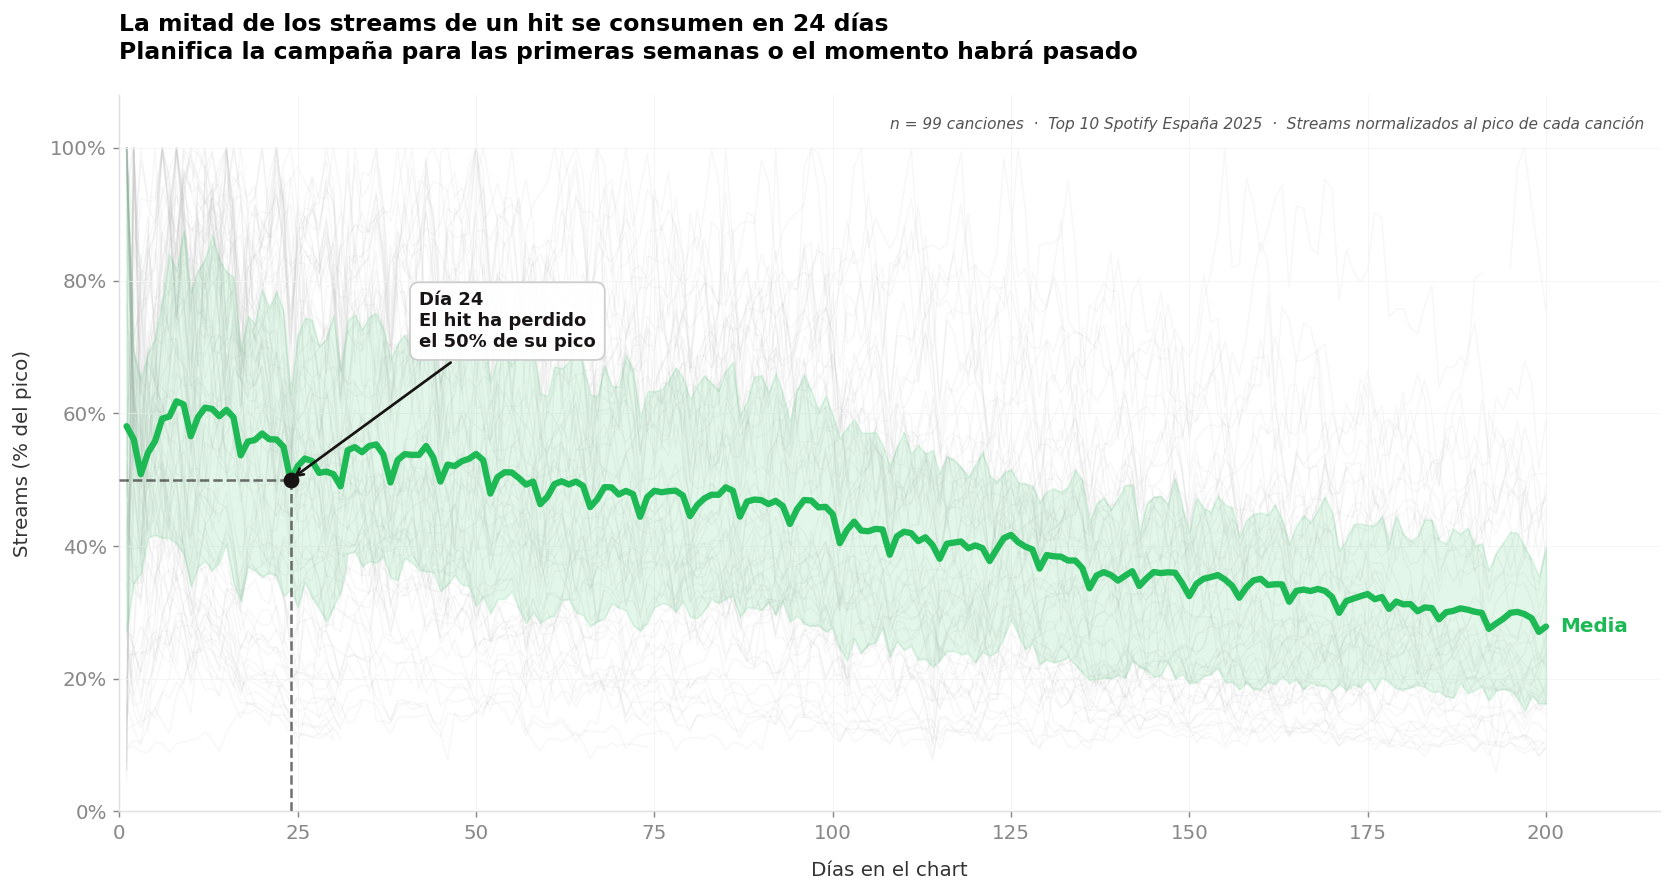

In [7]:
fig, ax = plt.subplots(figsize=(13, 7))

# ── 1. Ruido de fondo: curvas individuales (gris, muy transparente) ───
for _, group in lifecycle.groupby(['track_name', 'artist_names']):
    g = group.sort_values('days_on_chart')
    ax.plot(g['days_on_chart'], g['streams_norm'],
            color=GREY, alpha=0.10, linewidth=0.8, zorder=1)

# ── 2. Banda de confianza p25–p75 (protagonista secundario) ──────────
ax.fill_between(summary['days_on_chart'], summary['p25'], summary['p75'],
                color=GREEN, alpha=0.12, zorder=2, label='_nolegend_')

# ── 3. Curva media (protagonista principal) ───────────────────────────
ax.plot(summary['days_on_chart'], summary['media'],
        color=GREEN, linewidth=3.5, zorder=3, solid_capstyle='round')

# ── 4. Líneas de referencia del half-life ─────────────────────────────
if half_life:
    ax.plot([half_life, half_life], [0, 0.50],
            color=BLACK, linestyle='--', linewidth=1.4, alpha=0.6, zorder=4)
    ax.plot([0, half_life], [0.50, 0.50],
            color=BLACK, linestyle='--', linewidth=1.4, alpha=0.6, zorder=4)
    # Punto de intersección
    ax.scatter([half_life], [0.50], color=BLACK, s=60, zorder=5)

    # ── 5. Anotación directa (sin leyenda) ───────────────────────────
    ax.annotate(
        f'Día {half_life}\nEl hit ha perdido\nel 50% de su pico',
        xy=(half_life, 0.50),
        xytext=(half_life + 18, 0.70),
        fontsize=10, color=BLACK, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=BLACK, lw=1.5),
        bbox=dict(boxstyle='round,pad=0.5', fc=WHITE, ec='#CCCCCC', alpha=0.95)
    )

# ── 6. Etiqueta directa sobre la curva media ─────────────────────────
last = summary.iloc[-1]
ax.text(last['days_on_chart'] + 2, last['media'],
        'Media', color=GREEN, fontweight='bold', fontsize=11, va='center')

# ── 7. Nota metodológica ──────────────────────────────────────────────
ax.text(0.99, 0.97,
        f'n = {n_songs} canciones  ·  Top 10 Spotify España 2025  ·  Streams normalizados al pico de cada canción',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=8.5, color=DARK, style='italic')

# ── Formato ───────────────────────────────────────────────────────────
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xlim(0, MAX_DAYS * 1.08)
ax.set_ylim(0, 1.08)
ax.set_xlabel('Días en el chart', labelpad=10)
ax.set_ylabel('Streams (% del pico)', labelpad=10)

hl_str = str(half_life) if half_life else '?'
ax.set_title(
    f'La mitad de los streams de un hit se consumen en {hl_str} días\n'
    'Planifica la campaña para las primeras semanas o el momento habrá pasado',
    loc='left', pad=20
)

plt.tight_layout()
plt.savefig('viz_A_reloj_de_arena.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Acto II — Boom o Slow Burner
### *Dos patrones de éxito. Dos estrategias de lanzamiento.*

> **Big Idea:** No todos los hits funcionan igual.  
> Los **Boom** explotan en el debut y se desinflan rápido.  
> Los **Slow Burners** crecen despacio pero construyen audiencias más fieles.  
> Tratarlos con la misma estrategia es desperdiciar presupuesto.

**Principios SWD aplicados:**
- **Pequeños múltiplos:** dos paneles con ejes idénticos para comparación honesta y directa
- **Atributos preatentivos — color:** rojo (urgencia, explosión) vs azul (constancia, crecimiento)
- **El fondo gris es obligatorio:** hace visible la variabilidad y da credibilidad estadística al argumento
- **Anotaciones con datos:** los porcentajes clave van sobre el gráfico, no en una tabla aparte

In [8]:
# ── Clasificación Boom / Slow Burner ─────────────────────────────────
# Criterio: correlación de Pearson entre days_on_chart y streams
#   Correlación negativa → streams decrecen con la edad → BOOM
#   Correlación positiva → streams crecen con la edad  → SLOW BURNER

# Solo canciones con rango suficiente de days_on_chart (>= 20 días)
# y que hayan llegado al top 20 (canciones relevantes)
song_meta = (
    df.groupby(['track_name', 'artist_names'])
    .agg(
        n_obs      = ('streams',       'count'),
        days_min   = ('days_on_chart', 'min'),
        days_max   = ('days_on_chart', 'max'),
        best_rank  = ('rank',          'min')
    )
    .reset_index()
)
song_meta['day_range'] = song_meta['days_max'] - song_meta['days_min']

eligible = song_meta[
    (song_meta['day_range'] >= 20) &
    (song_meta['n_obs'] >= 5) &
    (song_meta['best_rank'] <= 20)
][['track_name', 'artist_names']]

print(f'Canciones elegibles para clasificación: {len(eligible)}')

# Calcular correlación days_on_chart ↔ streams para cada canción
df_eligible = df.merge(eligible, on=['track_name', 'artist_names'])

corr_list = []
for (track, artist), g in df_eligible.groupby(['track_name', 'artist_names']):
    if len(g) >= 5:
        corr = g['days_on_chart'].corr(g['streams'])
        corr_list.append({'track_name': track, 'artist_names': artist, 'corr': corr})

corr_df = pd.DataFrame(corr_list)
corr_df['hit_type'] = corr_df['corr'].apply(
    lambda c: 'Slow Burner' if c >= 0 else 'Boom'
)

print('\nDistribución de tipos:')
print(corr_df['hit_type'].value_counts().to_string())

boom_songs = corr_df[corr_df['hit_type'] == 'Boom'][['track_name', 'artist_names']]
slow_songs = corr_df[corr_df['hit_type'] == 'Slow Burner'][['track_name', 'artist_names']]

print('\nEjemplos BOOM (streams altos al debut, bajan después):')
print(boom_songs.head(5)[['artist_names', 'track_name']].to_string(index=False))
print('\nEjemplos SLOW BURNER (streams crecen con el tiempo):')
print(slow_songs.head(5)[['artist_names', 'track_name']].to_string(index=False))

Canciones elegibles para clasificación: 149

Distribución de tipos:
hit_type
Boom           134
Slow Burner     15

Ejemplos BOOM (streams altos al debut, bajan después):
                              artist_names   track_name
                                 Yan Block          111
Yan Block, De La Rose, Hades66, Ñengo Flow  444 - Remix
                                    Aitana 6 DE FEBRERO
                                 Bad Bunny  ALAMBRE PúA
                          Mora, De La Rose       AURORA

Ejemplos SLOW BURNER (streams crecen con el tiempo):
                                                artist_names             track_name
                                Juseph, La Pantera, Lucho RK               CUPIDOxX
                                       El Bogueto, Yung Beef Cuando No Era Cantante
                          Héctor "El Father", Wisin & Yandel            El Teléfono
HUNTR/X, EJAE, AUDREY NUNA, REI AMI, KPop Demon Hunters Cast                 Golden
                   

In [9]:
# ── Construir curvas medias por tipo ──────────────────────────────────
MAX_DAYS_B = 180

def build_type_curve(song_list):
    data = df.merge(song_list, on=['track_name', 'artist_names']).copy()
    data['streams_norm'] = (
        data.groupby(['track_name', 'artist_names'])['streams']
        .transform(lambda x: x / x.max())
    )
    data = data[data['days_on_chart'] <= MAX_DAYS_B]
    curve = (
        data.groupby('days_on_chart')['streams_norm']
        .mean()
        .reset_index(name='media')
        .sort_values('days_on_chart')
    )
    return data, curve

boom_data, boom_curve = build_type_curve(boom_songs)
slow_data, slow_curve = build_type_curve(slow_songs)

# KPIs para las anotaciones
def kpi_at_day(curve, day, window=5):
    subset = curve[curve['days_on_chart'].between(day - window, day + window)]
    return subset['media'].mean() if len(subset) > 0 else np.nan

boom_w1  = kpi_at_day(boom_curve, 7)
slow_w1  = kpi_at_day(slow_curve, 7)
boom_d90 = kpi_at_day(boom_curve, 90)
slow_d90 = kpi_at_day(slow_curve, 90)

print(f'BOOM  — streams en semana 1:  {boom_w1:.0%}')
print(f'BOOM  — streams en día 90:    {boom_d90:.0%}')
print(f'SLOW  — streams en semana 1:  {slow_w1:.0%}')
print(f'SLOW  — streams en día 90:    {slow_d90:.0%}')

BOOM  — streams en semana 1:  60%
BOOM  — streams en día 90:    47%
SLOW  — streams en semana 1:  42%
SLOW  — streams en día 90:    68%


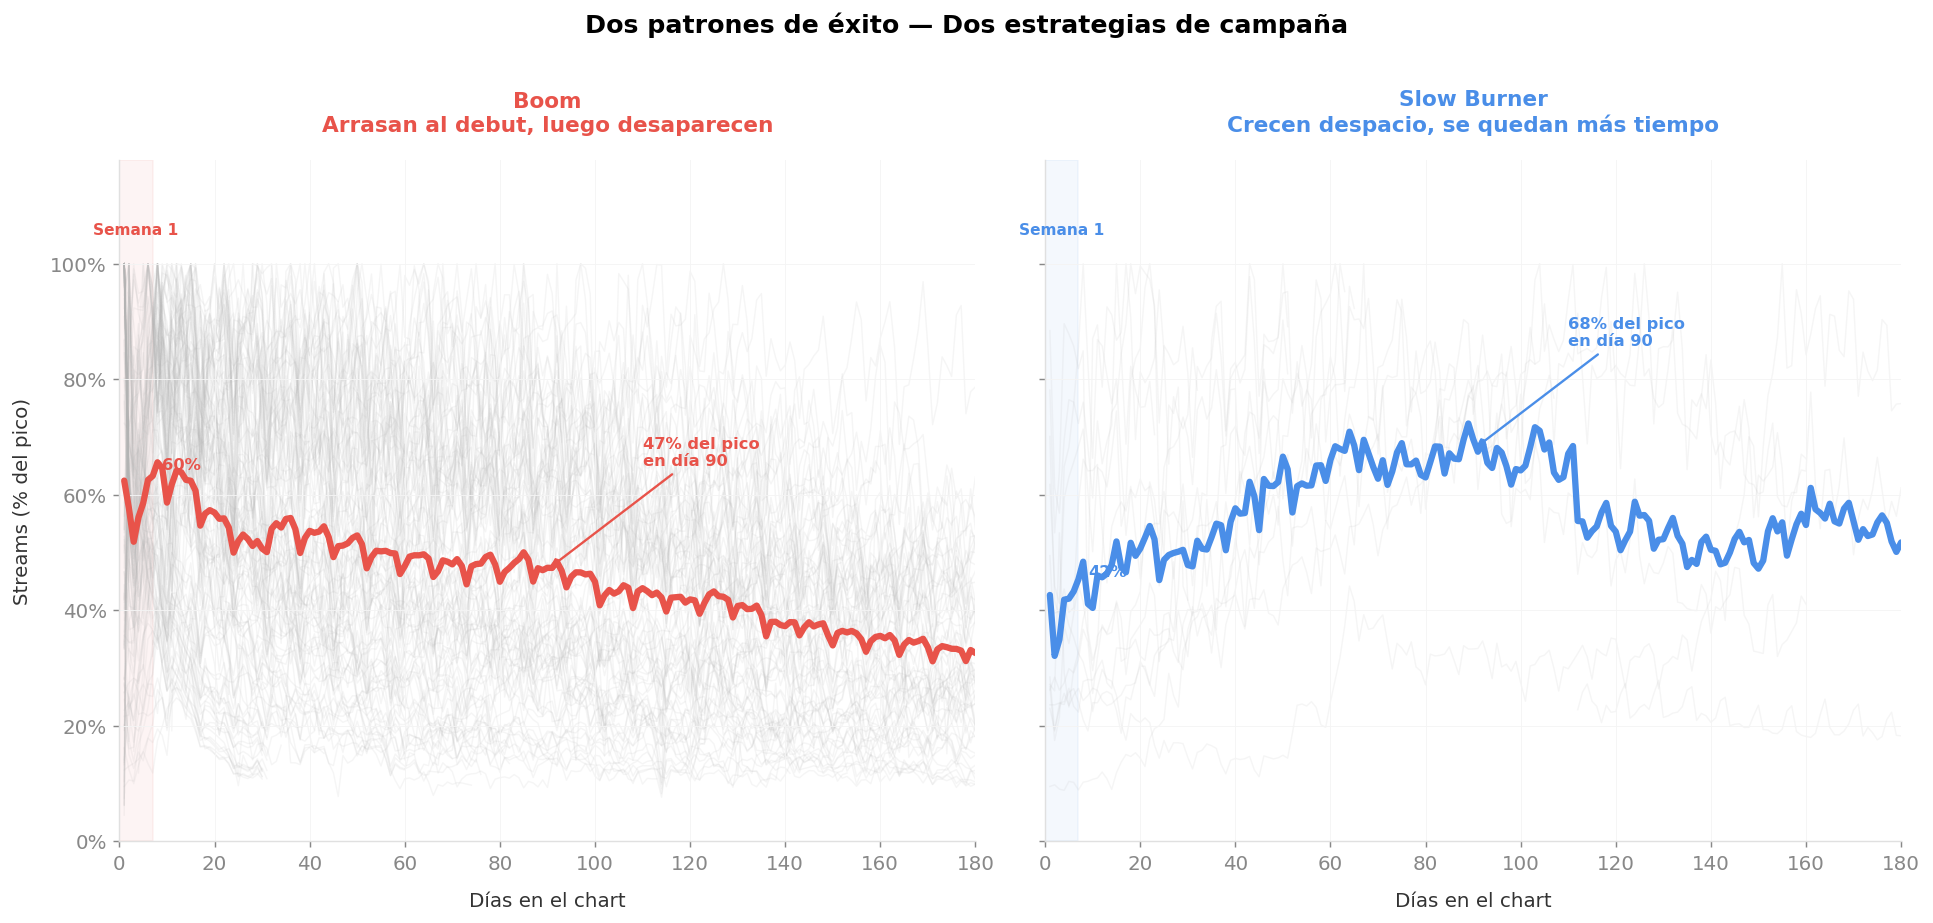

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
fig.patch.set_facecolor(WHITE)

panels = [
    (axes[0], boom_data, boom_curve, RED,  'Boom',
     'Arrasan al debut, luego desaparecen', boom_w1, boom_d90),
    (axes[1], slow_data, slow_curve, BLUE, 'Slow Burner',
     'Crecen despacio, se quedan más tiempo', slow_w1, slow_d90),
]

for ax, raw, curve, color, label, desc, kpi_w1, kpi_d90 in panels:

    # Fondo: ruido gris de canciones individuales
    for _, g in raw.groupby(['track_name', 'artist_names']):
        g = g.sort_values('days_on_chart')
        ax.plot(g['days_on_chart'], g['streams_norm'],
                color=GREY, alpha=0.12, linewidth=0.8, zorder=1)

    # Franja de la primera semana
    ax.axvspan(0, 7, alpha=0.06, color=color, zorder=0)
    ax.text(3.5, 1.05, 'Semana 1', ha='center', fontsize=8.5,
            color=color, fontweight='bold')

    # Curva media (protagonista)
    c = curve.sort_values('days_on_chart')
    ax.plot(c['days_on_chart'], c['media'],
            color=color, linewidth=3.5, zorder=3, solid_capstyle='round')

    # Anotación KPI en día 90
    if not np.isnan(kpi_d90):
        ax.annotate(
            f'{kpi_d90:.0%} del pico\nen día 90',
            xy=(90, kpi_d90),
            xytext=(110, kpi_d90 + 0.18),
            fontsize=9, color=color, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=color, lw=1.3)
        )

    # Anotación KPI en semana 1
    if not np.isnan(kpi_w1):
        ax.text(9, kpi_w1 + 0.04, f'{kpi_w1:.0%}',
                fontsize=9, color=color, fontweight='bold')

    ax.set_title(f'{label}\n{desc}', color=color, pad=16, fontsize=12)
    ax.set_xlabel('Días en el chart', labelpad=10)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.set_xlim(0, MAX_DAYS_B)
    ax.set_ylim(0, 1.18)

axes[0].set_ylabel('Streams (% del pico)', labelpad=10)

fig.suptitle('Dos patrones de éxito — Dos estrategias de campaña',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('viz_B_boom_vs_slow.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Acto III — Los Inmortales
### *Cuando una canción deja de ser un hit y se convierte en un activo*

> **Big Idea:** Un puñado de canciones desafía completamente la lógica del streaming.  
> Mientras el hit medio dura semanas, algunas canciones llevan **más de 6 años** entre  
> las más escuchadas de España. No son hits: son activos de catálogo que generan  
> ingresos sin coste de promoción.

**Principios SWD aplicados:**
- **El outlier es el argumento:** la forma de la distribución hace que el fenómeno se explique solo
- **Intensidad como atributo preatentivo:** de gris claro a verde intenso según longevidad
- **Anotación directa sobre los outliers:** nombre + años en el gráfico, no en tabla aparte
- **Segunda visualización con argumento económico:** transforma el insight técnico en decisión de negocio

In [11]:
# ── Longevidad máxima observada por canción ───────────────────────────
longevity = (
    df.groupby(['track_name', 'artist_names'])
    .agg(
        max_days     = ('days_on_chart', 'max'),
        mean_streams = ('streams',       'mean'),
        best_rank    = ('rank',          'min')
    )
    .reset_index()
)
longevity['years'] = longevity['max_days'] / 365

def categorize(d):
    if d >= 1825: return '5  Eterno (5+ años)'
    if d >= 1095: return '4  Resistente (3–5 años)'
    if d >= 365:  return '3  Longevo (1–3 años)'
    if d >= 90:   return '2  Establecido (3–12 meses)'
    return       '1  Efímero (< 3 meses)'

longevity['categoria'] = longevity['max_days'].apply(categorize)

# Inmortales (5+ años)
immortals = longevity[longevity['max_days'] >= 1825].sort_values('max_days', ascending=False)

print('CANCIONES INMORTALES (5+ años en el Top 50 de España)')
print('=' * 60)
for _, row in immortals.iterrows():
    name  = row['track_name']
    art   = row['artist_names'].split(',')[0]
    years = row['years']
    days  = row['max_days']
    print(f'  {years:.1f} años  ({days} días)  {name}  —  {art}')

p50 = longevity['max_days'].median()
p90 = longevity['max_days'].quantile(0.90)
print(f'\nMediana de longevidad (todas):  {p50:.0f} días  ({p50/365:.1f} años)')
print(f'Percentil 90:                   {p90:.0f} días  ({p90/365:.1f} años)')
print(f'% de canciones con 5+ años:     {len(immortals)/len(longevity):.1%}')

CANCIONES INMORTALES (5+ años en el Top 50 de España)
  7.4 años  (2699 días)  Soldadito marinero  —  Fito y Fitipaldis
  6.9 años  (2507 días)  Me Rehúso  —  Danny Ocean
  5.4 años  (1964 días)  El Fin del Mundo  —  La La Love You
  5.2 años  (1890 días)  Princesas  —  Pereza

Mediana de longevidad (todas):  26 días  (0.1 años)
Percentil 90:                   515 días  (1.4 años)
% de canciones con 5+ años:     0.3%


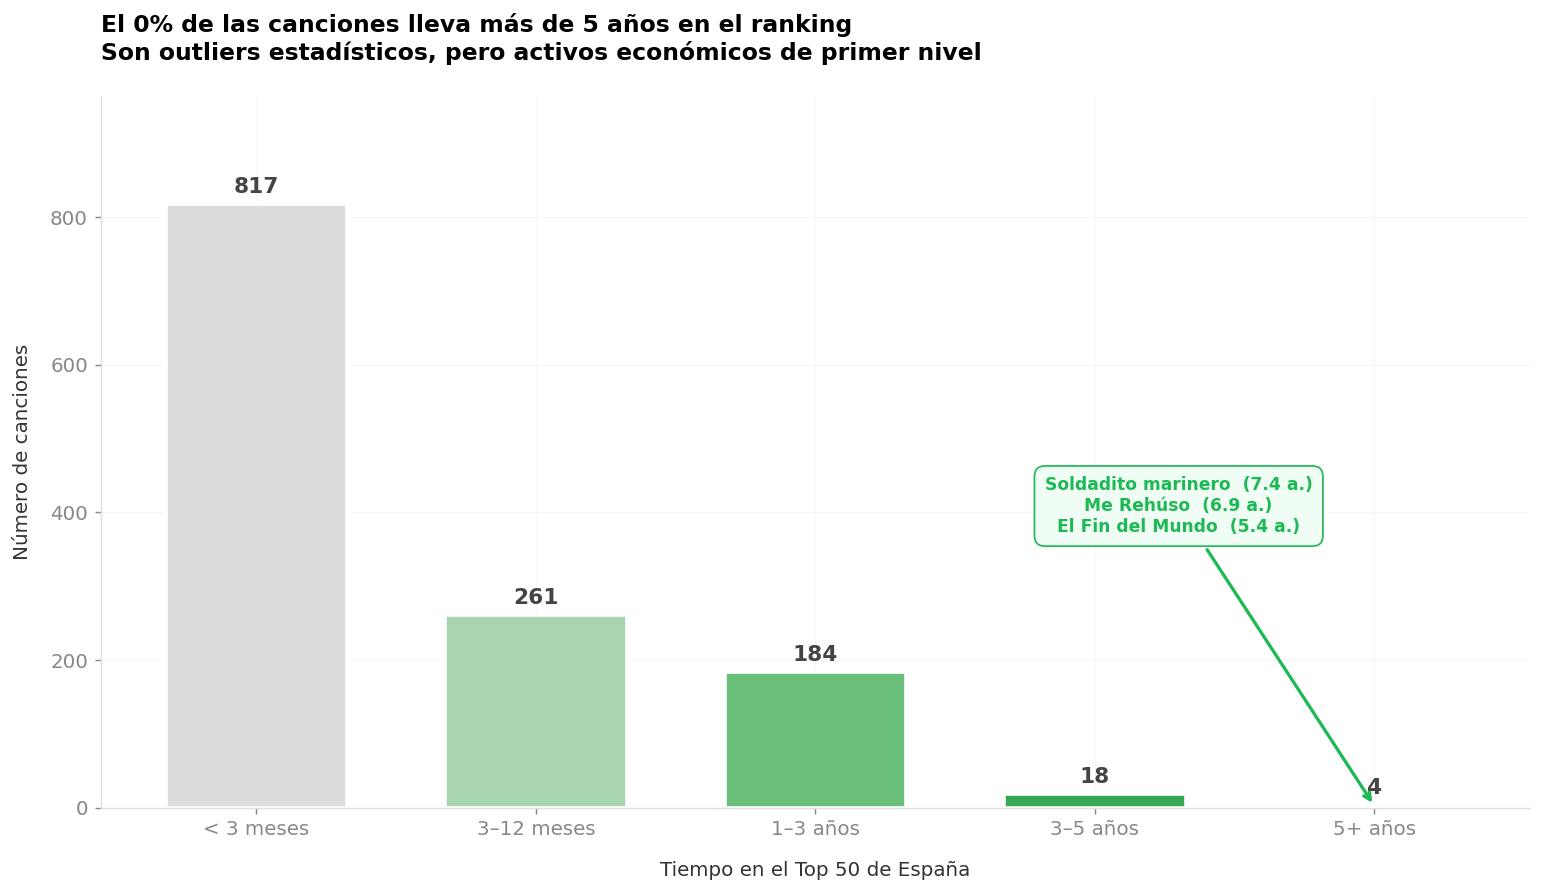

In [12]:
# ── Visualización C: distribución de longevidad ───────────────────────

# Paleta de verde (más verde = más longevo)
cat_order  = [
    '1  Efímero (< 3 meses)',
    '2  Establecido (3–12 meses)',
    '3  Longevo (1–3 años)',
    '4  Resistente (3–5 años)',
    '5  Eterno (5+ años)'
]
cat_labels = ['< 3 meses', '3–12 meses', '1–3 años', '3–5 años', '5+ años']
cat_colors = ['#DCDCDC', '#A8D5B0', '#6AC07A', '#36A853', GREEN]
bins       = [0, 90, 365, 1095, 1825, longevity['max_days'].max() + 1]

counts, _ = np.histogram(longevity['max_days'], bins=bins)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(WHITE)

bars = ax.bar(
    range(len(counts)), counts,
    color=cat_colors, edgecolor=WHITE, linewidth=2, width=0.65, zorder=2
)

# Valor sobre cada barra
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(counts) * 0.012,
        str(count),
        ha='center', va='bottom', fontsize=12, fontweight='bold', color='#444444'
    )

# Anotación de los inmortales (outliers)
if len(immortals) > 0:
    top3 = immortals.head(3)
    label_text = '\n'.join([
        f"{row['track_name'].split('(')[0].strip()}  ({row['years']:.1f} a.)"
        for _, row in top3.iterrows()
    ])
    ax.annotate(
        label_text,
        xy=(4, counts[-1] / 2 + 0.5),
        xytext=(3.3, max(counts) * 0.50),
        fontsize=9.5, color=GREEN, fontweight='bold',
        ha='center', va='center',
        arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.8),
        bbox=dict(boxstyle='round,pad=0.6', fc='#F0FDF4', ec=GREEN, alpha=0.95)
    )

# Etiquetas del eje x
ax.set_xticks(range(len(cat_labels)))
ax.set_xticklabels(cat_labels, fontsize=11)
ax.set_ylabel('Número de canciones', labelpad=10)
ax.set_xlabel('Tiempo en el Top 50 de España', labelpad=12)
ax.set_ylim(0, max(counts) * 1.18)

imm_pct = len(immortals) / len(longevity)
ax.set_title(
    f'El {imm_pct:.0%} de las canciones lleva más de 5 años en el ranking\n'
    'Son outliers estadísticos, pero activos económicos de primer nivel',
    loc='left', pad=20
)

plt.tight_layout()
plt.savefig('viz_C_longevidad_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

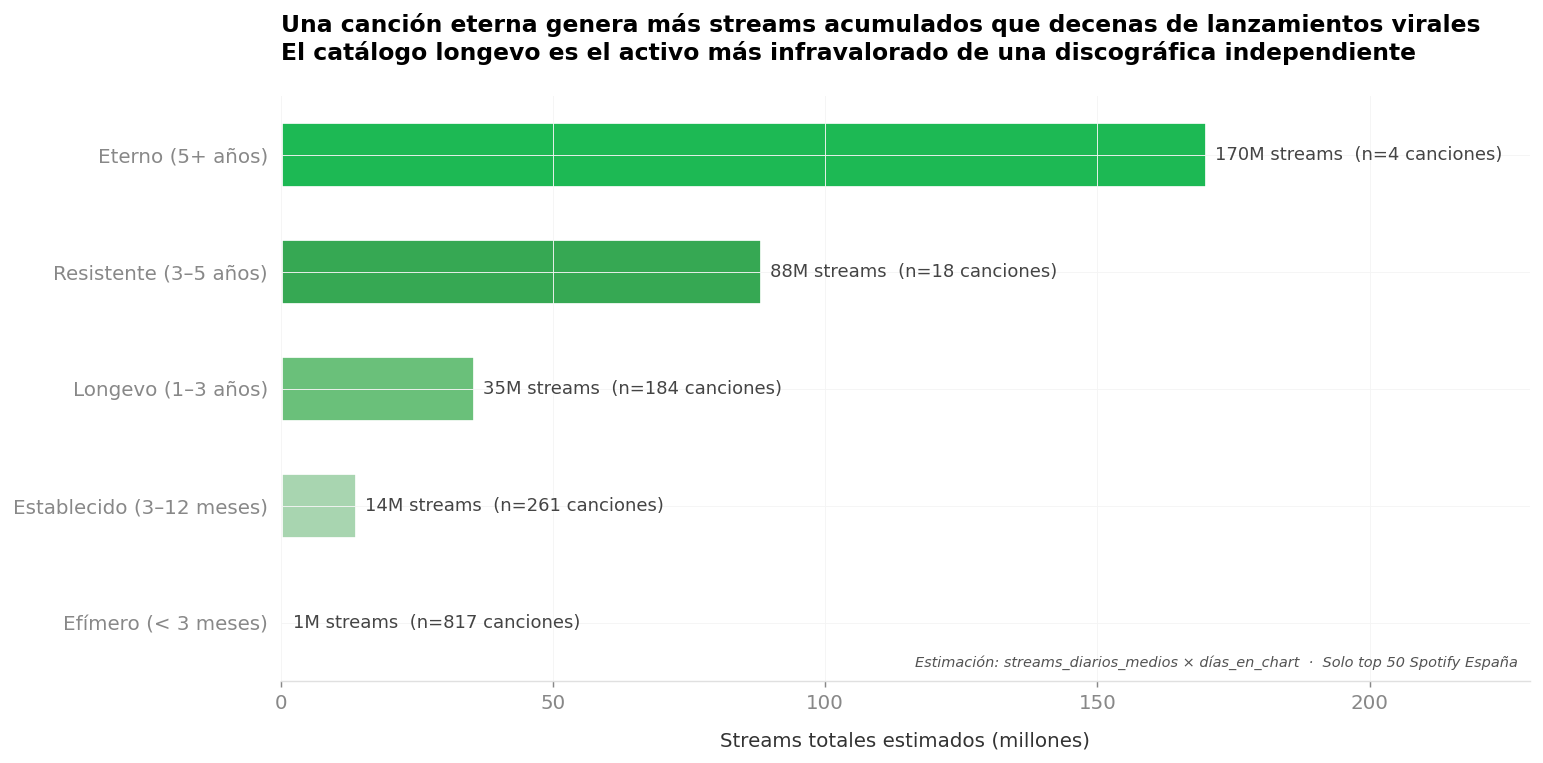

In [13]:
# ── Visualización D: valor económico estimado por categoría ──────────
# Proxy: streams_diarios_medios × días_en_chart (valor de catálogo acumulado)

value_df = (
    longevity
    .groupby('categoria')
    .agg(
        n            = ('max_days',     'count'),
        days_median  = ('max_days',     'median'),
        streams_med  = ('mean_streams', 'median')
    )
    .reset_index()
)
value_df['valor_M'] = (value_df['days_median'] * value_df['streams_med']) / 1e6
value_df = value_df.sort_values('valor_M', ascending=True)

# Colores por categoría
color_map = dict(zip(cat_order, cat_colors))
bar_colors = [color_map.get(c, GREY) for c in value_df['categoria']]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(WHITE)

bars = ax.barh(
    value_df['categoria'].str[3:],   # eliminar el prefijo de orden
    value_df['valor_M'],
    color=bar_colors, edgecolor=WHITE, linewidth=1.5, height=0.55
)

# Etiquetas de valor
for bar, (_, row) in zip(bars, value_df.iterrows()):
    w = bar.get_width()
    ax.text(
        w + value_df['valor_M'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{w:.0f}M streams  (n={row["n"]} canciones)',
        va='center', fontsize=10, color='#444444'
    )

ax.set_xlabel('Streams totales estimados (millones)', labelpad=10)
ax.set_xlim(0, value_df['valor_M'].max() * 1.35)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

ax.set_title(
    'Una canción eterna genera más streams acumulados que decenas de lanzamientos virales\n'
    'El catálogo longevo es el activo más infravalorado de una discográfica independiente',
    loc='left', pad=20
)

# Nota metodológica
ax.text(0.99, 0.02,
        'Estimación: streams_diarios_medios × días_en_chart  ·  Solo top 50 Spotify España',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8, color=DARK, style='italic')

plt.tight_layout()
plt.savefig('viz_D_valor_catalogo.png', dpi=150, bbox_inches='tight')
plt.show()

---

## La Recomendación para SurLabel

Esto es lo que los datos dicen antes del lunes:

| Insight | Dato clave | Implicación práctica |
|---|---|---|
| **El reloj de arena** | Un hit pierde el 50% de sus streams en ~X días | Escalonar los tres lanzamientos; no lanzar dos a la vez |
| **Boom vs Slow Burner** | Dos patrones de crecimiento claramente distintos | Adaptar el presupuesto y el timing de campaña al tipo de hit |
| **El catálogo es un activo** | Las canciones longevas acumulan más valor total | Revisar el catálogo propio antes de invertir en nuevos lanzamientos |

---

### Lo que este análisis NO dice

Un buen data storyteller no solo comunica lo que los datos muestran.  
También comunica honestamente lo que los datos **no** pueden responder:

- **Causalidad:** los patrones observados no explican *por qué* una canción dura o desaparece
- **Calidad musical:** no hay ninguna variable de calidad artística en el dataset
- **Sesgos del dataset:** solo registramos canciones que llegaron al top 50; todo lo que no entró es invisible
- **Generalización temporal:** estos patrones corresponden a 2025; el mercado puede cambiar

---

*Herramientas: Python · pandas · matplotlib · Spotify Charts España 2025*  
*Marco teórico: Storytelling with Data, Cole Nussbaumer Knaflic (2015)*